# MLP Hyperparameter Tuning — scikit-optimize (skopt) Bayesian Optimisation

## What scikit-optimize does

`scikit-optimize` (skopt) is a Bayesian optimisation library that integrates directly with
scikit-learn's API. Its `BayesSearchCV` is a drop-in replacement for `GridSearchCV` and
`RandomizedSearchCV` but searches *intelligently* rather than randomly.

### How it differs from Optuna

| Feature | scikit-optimize (`BayesSearchCV`) | Optuna (TPE) |
|---|---|---|
| Surrogate model | Gaussian Process (GP) | Tree-structured Parzen Estimator |
| Acquisition function | Expected Improvement (EI) | EI via density ratio |
| sklearn API | Native (`BayesSearchCV`) | Manual objective function |
| Conditional params | Not natively supported | Fully supported |
| Scalability | Slower for >10 params (GP cost) | Scales well |
| Visualisation | `plot_convergence`, `plot_objective` | Rich built-in plots |

### Why BayesSearchCV is convenient

If you already know sklearn's `GridSearchCV` API, `BayesSearchCV` is almost identical —
you just swap `RandomizedSearchCV` for `BayesSearchCV` and replace uniform distributions
with `Real`, `Integer`, and `Categorical` space objects. The surrogate GP models the
mapping from hyperparameters → CV score, then the acquisition function decides where
to sample next to maximise expected improvement.

**Objective**: minimise CV MAE (skopt's scorer interface), then convert the best
model to NMAD for direct comparison.

In [15]:
# Install scikit-optimize if not already present
import importlib, subprocess, sys
if importlib.util.find_spec('skopt') is None:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'scikit-optimize', '-q'])
print('scikit-optimize ready.')

scikit-optimize ready.


In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from astropy.stats import sigma_clip
from sklearn.model_selection import train_test_split, cross_val_predict
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.inspection import permutation_importance

from skopt import BayesSearchCV
from skopt.space import Real, Categorical, Integer
from skopt.plots import plot_convergence, plot_objective, plot_evaluations

SEED = 42
np.random.seed(SEED)
print('Libraries loaded.')

Libraries loaded.


---
## Data Loading & Quality Cuts

Identical pipeline to `multilayer perceptron learning.ipynb` — same cuts, same train/test split,
same random seed so results are directly comparable.

In [17]:
df = pd.read_csv('ZTF_DESI_ml_work/ZTF_DESI_data/ZTF_resid_cent_hostprop_no_x1_c.csv')
print(len(df), 'SNe before quality cuts.')

df = df[(df['lccoverage_flag'] == 1) & (df['fitquality_flag'] == 1)]
print(len(df), 'SNe after lccoverage + fitquality flags.')

df['SDSS_g_minus_r'] = df['ABSMAG01_SDSS_G'] - df['ABSMAG01_SDSS_R']

clip = sigma_clip(df['residual_centered'], sigma=3, maxiters=1)
df = df.loc[~clip.mask].reset_index(drop=True)
print(len(df), 'SNe after 3-sigma clip.')

df = df.loc[df['SFR'] <= 2.5].reset_index(drop=True)
df = df.loc[df['DN4000'] >= 0.5].reset_index(drop=True)
df = df.loc[df['AGE'] >= 2].reset_index(drop=True)
print(len(df), 'SNe after physical host-galaxy cuts.')

yerr_all = df['sigma_mu_meas'].copy()

776 SNe before quality cuts.
579 SNe after lccoverage + fitquality flags.
563 SNe after 3-sigma clip.
550 SNe after physical host-galaxy cuts.


In [18]:
feature_cols = [
    'LOGMSTAR', 'c', 'x1', 'SFR', 'VDISP',
    'DN4000', 'SDSS_g_minus_r', 'AGE', 'redshift',
]
target_col = 'residual_centered'

X = df[feature_cols].copy()
y = df[target_col].copy()

Xtr, Xte, ytr, yte, yerr_tr, yerr_te = train_test_split(
    X, y, yerr_all, test_size=0.2, random_state=SEED
)
print(f'Training : {len(Xtr)} samples')
print(f'Test     : {len(Xte)} samples')

Training : 440 samples
Test     : 110 samples


---
## Helper Functions

In [19]:
def nmad(y_true, y_pred):
    """Normalised median absolute deviation — standard SN cosmology scatter metric."""
    return 1.4826 * float(np.median(np.abs(np.asarray(y_pred) - np.asarray(y_true))))


def outlier_rate(y_true, y_pred, threshold=0.1):
    """Fraction of predictions with |residual| > threshold mag."""
    return 100.0 * float(np.mean(np.abs(np.asarray(y_true) - np.asarray(y_pred)) > threshold))


def cv_scores(pipe, X, y, cv=5):
    """Return (NMAD, outlier_rate) via cross_val_predict."""
    yp = cross_val_predict(pipe, X, y, cv=cv)
    return nmad(y, yp), outlier_rate(y, yp)


print('Helpers defined.')

Helpers defined.


In [20]:
# skopt serialises Categorical values through JSON internally, which converts
# tuples → lists.  The subsequent `check_x_in_space` equality check then fails
# because (64, 32) != [64, 32].  Workaround: store architectures as strings and
# decode to tuples inside a thin MLPRegressor subclass.

_ARCH_MAP = {
    '16':        (16,),
    '32':        (32,),
    '64':        (64,),
    '128':       (128,),
    '32_16':     (32, 16),
    '64_32':     (64, 32),
    '128_64':    (128, 64),
    '64_32_16':  (64, 32, 16),
    '128_64_32': (128, 64, 32),
}


class StrArchMLPRegressor(MLPRegressor):
    """MLPRegressor that accepts hidden_layer_sizes as a string key.

    BayesSearchCV passes the sampled string (e.g. '64_32') to set_params;
    this class decodes it to the correct tuple before calling sklearn's fit,
    then restores the string so get_params() stays consistent with the search space.
    """

    def _decode_arch(self):
        hls = self.hidden_layer_sizes
        return _ARCH_MAP.get(hls, hls) if isinstance(hls, str) else hls

    def fit(self, X, y, **kw):
        orig = self.hidden_layer_sizes
        self.hidden_layer_sizes = self._decode_arch()
        super().fit(X, y, **kw)
        self.hidden_layer_sizes = orig   # restore so get_params() is stable
        return self


print('StrArchMLPRegressor defined.')

StrArchMLPRegressor defined.


---
## Search Space Definition

skopt uses typed space objects that communicate to the GP surrogate how each dimension
should be treated:

| Type | Usage | Notes |
|---|---|---|
| `Real(lo, hi, prior='log-uniform')` | Continuous log-scale | alpha, learning_rate |
| `Categorical([...])` | Unordered discrete choices | architecture, activation, solver |
| `Integer(lo, hi)` | Ordered integers | Not used here |

### Conditional parameter caveat

`BayesSearchCV` does **not** natively support conditional hyperparameters
(e.g., `learning_rate_init` only applies to `adam`). We include it in the space for all
solvers — `lbfgs` simply ignores the value. The GP surrogate will learn this redundancy
over trials, effectively marginalising over `learning_rate_init` when `solver=lbfgs`.

This is one area where Optuna is strictly more elegant.

In [21]:
search_space = {
    'mlp__hidden_layer_sizes': Categorical(list(_ARCH_MAP.keys())),  # strings, not tuples
    'mlp__activation'        : Categorical(['relu', 'tanh', 'logistic']),
    'mlp__solver'            : Categorical(['lbfgs', 'adam']),
    'mlp__alpha'             : Real(1e-5, 10.0, prior='log-uniform'),
    'mlp__learning_rate_init': Real(1e-4, 1e-1, prior='log-uniform'),
    'mlp__max_iter'          : Categorical([2000]),
    'mlp__early_stopping'    : Categorical([False]),
}

base_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('mlp', StrArchMLPRegressor(random_state=SEED)),
])

print('Search space defined.')
for param, space in search_space.items():
    print(f'  {param:<40s}  {space}')

Search space defined.
  mlp__hidden_layer_sizes                   Categorical(categories=('16', '32', '64', ..., '128_64', '64_32_16', '128_64_32'), prior=None)
  mlp__activation                           Categorical(categories=('relu', 'tanh', 'logistic'), prior=None)
  mlp__solver                               Categorical(categories=('lbfgs', 'adam'), prior=None)
  mlp__alpha                                Real(low=1e-05, high=10.0, prior='log-uniform', transform='identity')
  mlp__learning_rate_init                   Real(low=0.0001, high=0.1, prior='log-uniform', transform='identity')
  mlp__max_iter                             Categorical(categories=(2000,), prior=None)
  mlp__early_stopping                       Categorical(categories=(False,), prior=None)


---
## BayesSearchCV: Fit

We run **60 iterations** of Bayesian optimisation (each iteration = one full 5-fold CV).

Internally, `BayesSearchCV`:
1. Evaluates `n_initial_points=10` random configurations to warm-start the GP
2. Fits a Gaussian Process surrogate to the observed (params → CV MAE) mapping
3. Uses Expected Improvement (EI) to propose the next candidate
4. Repeats until `n_iter` exhausted

The `n_jobs=-1` parallelises CV folds within each iteration (not across iterations,
since each iteration depends on the GP updated by the previous one).

In [22]:
bscv = BayesSearchCV(
    base_pipe,
    search_space,
    n_iter=60,
    cv=5,
    n_jobs=-1,
    scoring='neg_mean_absolute_error',   # BayesSearchCV maximises score, so neg_MAE
    random_state=SEED,
    verbose=1,
    n_points=1,          # number of points proposed per iteration (1 = sequential GP)
    optimizer_kwargs={'n_initial_points': 10},  # random warm-up before GP kicks in
    refit=True,          # refit best model on full training set
)

bscv.fit(Xtr, ytr)

print(f'\nBayesSearchCV complete — {bscv.total_iterations} iterations.')
print(f'Best CV MAE : {-bscv.best_score_:.4f} mag')
print('Best params :')
for k, v in bscv.best_params_.items():
    print(f'  {k:<40s} = {v}')

Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits


/Users/pittsburghgraduatestudent/miniforge3/envs/ds2/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:546: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)
/Users/pittsburghgraduatestudent/miniforge3/envs/ds2/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:546: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)
/Users/pittsburghgraduatestudent/miniforge3/envs/ds2/lib/python3.11/site-packages/sklearn/neural_n

Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits


/Users/pittsburghgraduatestudent/miniforge3/envs/ds2/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:546: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)


Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fi

/Users/pittsburghgraduatestudent/miniforge3/envs/ds2/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:546: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)


Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fi

In [23]:
# BayesSearchCV optimised for MAE — now compute NMAD on the same CV folds
# for apples-to-apples comparison with the other notebooks.
best_skopt_pipe = bscv.best_estimator_
n_cv, o_cv = cv_scores(best_skopt_pipe, Xtr, ytr)
print(f'Best model CV NMAD (cross_val_predict) : {n_cv:.4f}')
print(f'Best model CV Outlier%                 : {o_cv:.1f}')

Best model CV NMAD (cross_val_predict) : 0.1493
Best model CV Outlier%                 : 50.7


---
## Visualising the Bayesian Optimisation

skopt's plotting tools visualise the GP surrogate and the search trajectory:

- **Convergence plot**: cumulative best CV score vs iterations — shows how fast the GP
  finds a good configuration and whether it has converged
- **Evaluations plot**: which regions of parameter space were sampled (scatter matrix)
- **Objective plot**: the GP surrogate surface for pairs of parameters

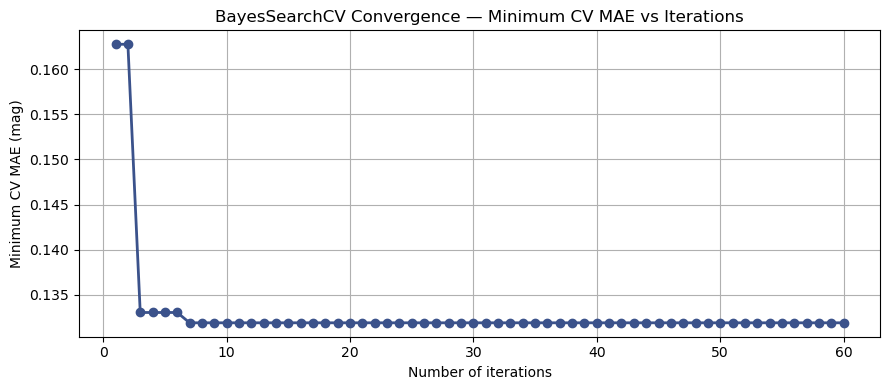

In [24]:
# --- Convergence plot ---
# Shows the minimum CV MAE found so far as a function of the number of calls.
# A flat tail means the search has converged; still dropping means more trials would help.
fig, ax = plt.subplots(figsize=(9, 4))
plot_convergence(bscv.optimizer_results_[0], ax=ax)
ax.set_title('BayesSearchCV Convergence — Minimum CV MAE vs Iterations')
ax.set_ylabel('Minimum CV MAE (mag)')
ax.set_xlabel('Number of iterations')
plt.tight_layout()
plt.show()

Evaluations plot skipped: cannot unpack non-iterable Axes object


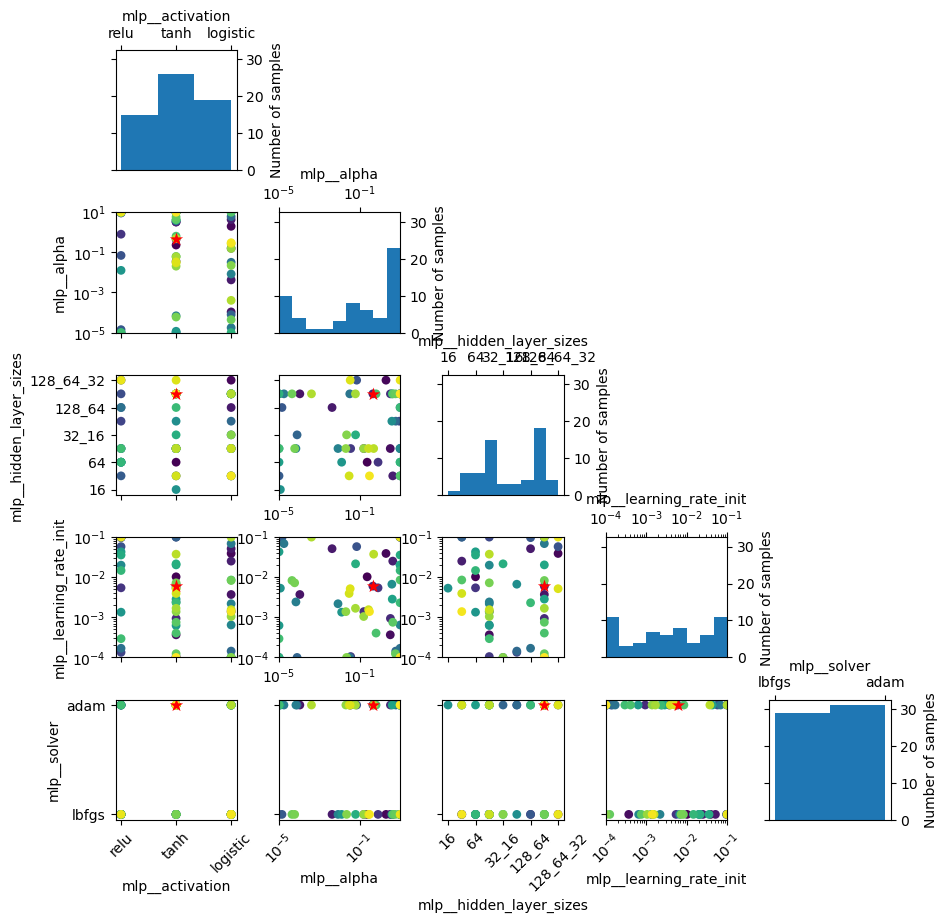

In [25]:
# --- Evaluations plot (continuous params only) ---
# Shows where in the (alpha, learning_rate_init) space the GP sampled.
# Early random points + later focused GP proposals should be visible.
try:
    res = bscv.optimizer_results_[0]
    fig, axes = plot_evaluations(res, bins=10)
    fig.suptitle('BayesSearchCV — Sampled Locations in Parameter Space', y=1.01)
    plt.tight_layout()
    plt.show()
except Exception as e:
    print(f'Evaluations plot skipped: {e}')

Objective plot skipped: cannot unpack non-iterable Axes object


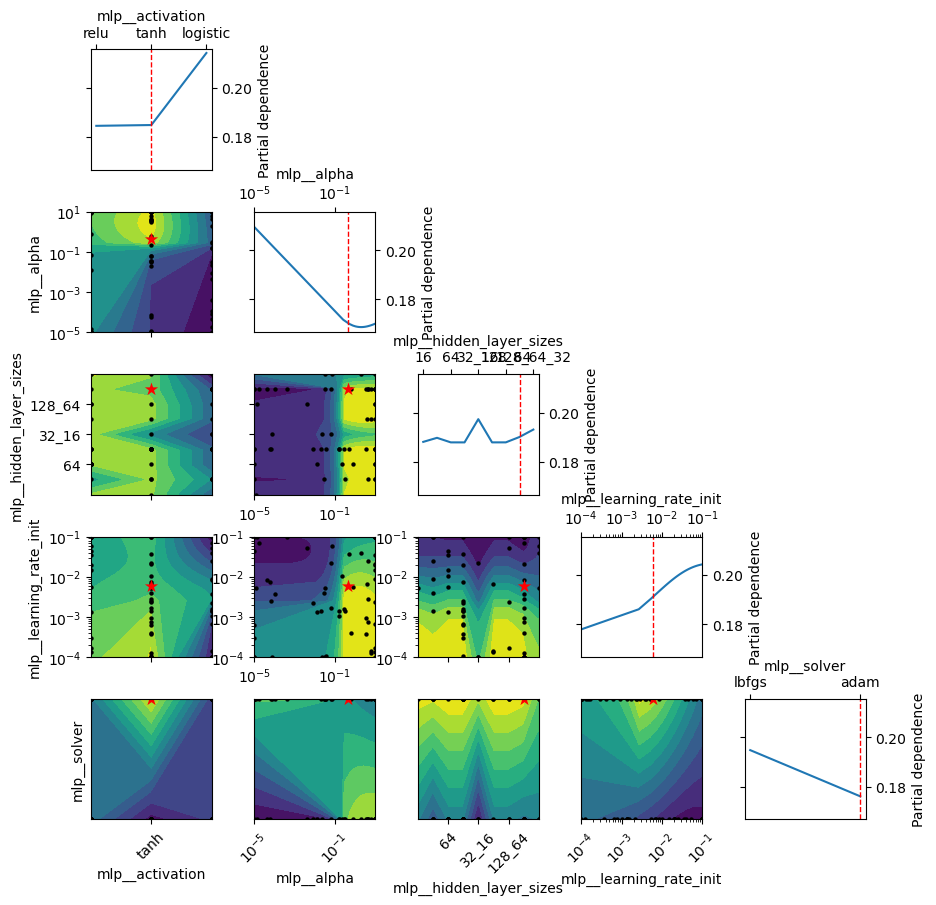

In [26]:
# --- GP surrogate surface for alpha vs learning_rate_init ---
# The diagonal shows the marginal surrogate for each parameter.
# Off-diagonal shows the 2D surrogate surface (partial dependence).
try:
    res = bscv.optimizer_results_[0]
    fig, axes = plot_objective(res, n_samples=50)
    fig.suptitle('GP Surrogate Objective Surface — BayesSearchCV', y=1.01)
    plt.tight_layout()
    plt.show()
except Exception as e:
    print(f'Objective plot skipped: {e}')

In [27]:
# --- Top-15 configurations by CV MAE ---
cv_df = pd.DataFrame(bscv.cv_results_)
cv_df['mean_cv_mae'] = -cv_df['mean_test_score']
top15 = cv_df.sort_values('mean_cv_mae').head(15)

param_cols = [c for c in cv_df.columns if c.startswith('param_')]
print('Top-15 configurations by CV MAE:')
print(top15[['mean_cv_mae', 'std_test_score'] + param_cols].to_string(index=False))

Top-15 configurations by CV MAE:
 mean_cv_mae  std_test_score param_mlp__activation  param_mlp__alpha  param_mlp__early_stopping param_mlp__hidden_layer_sizes  param_mlp__learning_rate_init  param_mlp__max_iter param_mlp__solver
    0.131882        0.011823                  tanh          0.448938                      False                      64_32_16                       0.005996                 2000              adam
    0.132742        0.012894              logistic          0.302879                      False                            32                       0.001390                 2000             lbfgs
    0.132880        0.010900                  tanh          0.489417                      False                           128                       0.037520                 2000              adam
    0.132973        0.010606                  tanh          0.642362                      False                      64_32_16                       0.000405                 2000      

---
## Final Model: Test-Set Evaluation

Because `refit=True`, `bscv.best_estimator_` is already refitted on the full training
set with the best-found parameters. We evaluate it once on the held-out test set.

In [28]:
yte_pred = best_skopt_pipe.predict(Xte)
ytr_pred = best_skopt_pipe.predict(Xtr)

test_nmad    = nmad(yte, yte_pred)
test_outlier = outlier_rate(yte, yte_pred)
test_mae     = mean_absolute_error(yte, yte_pred)
test_rmse    = float(np.sqrt(mean_squared_error(yte, yte_pred)))
test_r2      = r2_score(yte, yte_pred)
train_r2     = r2_score(ytr, ytr_pred)

print('=' * 55)
print('  SKOPT BEST MODEL — TEST-SET RESULTS')
print('=' * 55)
for k, v in bscv.best_params_.items():
    print(f'  {k.replace("mlp__", ""):<25s} = {v}')
print('-' * 55)
print(f'  CV NMAD      : {n_cv:.4f} mag')
print(f'  Test NMAD    : {test_nmad:.4f} mag')
print(f'  Outlier Rate : {test_outlier:.1f} %')
print(f'  Test MAE     : {test_mae:.4f} mag')
print(f'  Test RMSE    : {test_rmse:.4f} mag')
print(f'  R² (test)    : {test_r2:.4f}')
print(f'  R² (train)   : {train_r2:.4f}')
print(f'  ΔR² overfit  : {train_r2 - test_r2:.4f}')
print('=' * 55)

  SKOPT BEST MODEL — TEST-SET RESULTS
  activation                = tanh
  alpha                     = 0.4489379023123383
  early_stopping            = False
  hidden_layer_sizes        = 64_32_16
  learning_rate_init        = 0.005995964127756074
  max_iter                  = 2000
  solver                    = adam
-------------------------------------------------------
  CV NMAD      : 0.1493 mag
  Test NMAD    : 0.1397 mag
  Outlier Rate : 47.3 %
  Test MAE     : 0.1369 mag
  Test RMSE    : 0.1851 mag
  R² (test)    : 0.6780
  R² (train)   : 0.7646
  ΔR² overfit  : 0.0865


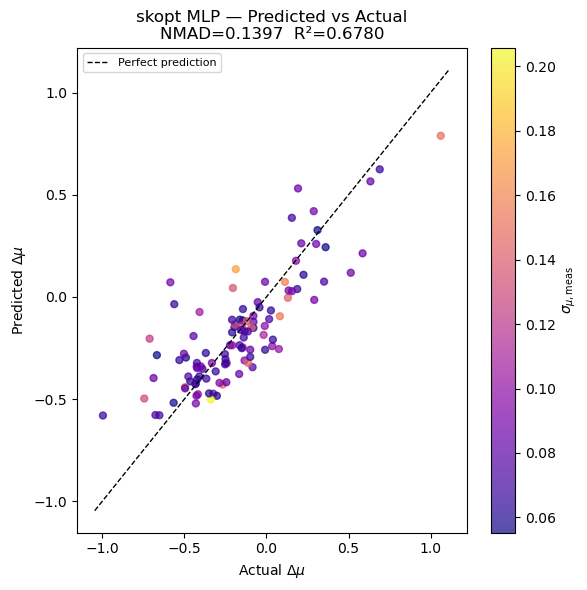

In [29]:
# --- Predicted vs Actual ---
yt = np.array(yte)
yp = np.array(yte_pred)
lo = min(yt.min(), yp.min()) - 0.05
hi = max(yt.max(), yp.max()) + 0.05

fig, ax = plt.subplots(figsize=(6, 6))
sc = ax.scatter(yt, yp, c=np.array(yerr_te), cmap='plasma', alpha=0.7, s=25)
ax.plot([lo, hi], [lo, hi], 'k--', linewidth=1, label='Perfect prediction')
ax.set_xlabel(r'Actual $\Delta\mu$')
ax.set_ylabel(r'Predicted $\Delta\mu$')
ax.set_title(f'skopt MLP — Predicted vs Actual\nNMAD={test_nmad:.4f}  R²={test_r2:.4f}')
ax.legend(fontsize=8)
plt.colorbar(sc, ax=ax, label=r'$\sigma_{\mu,\mathrm{meas}}$')
plt.tight_layout()
plt.show()

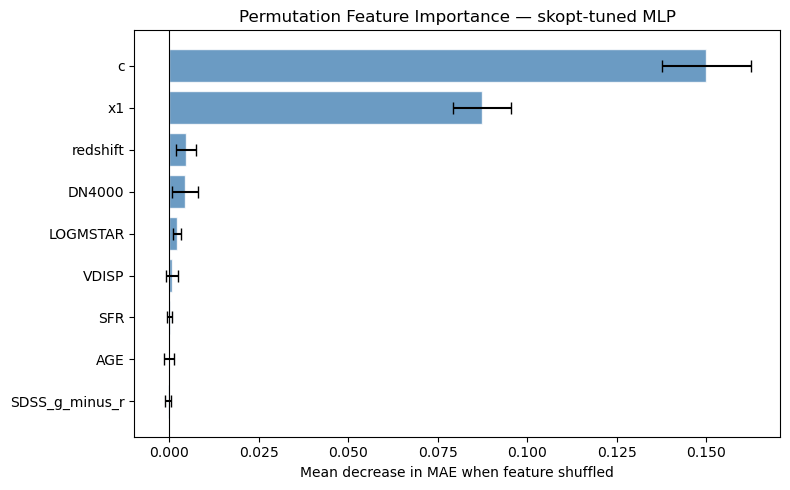

Feature importance (descending):
  c                     0.1500
  x1                    0.0873
  redshift              0.0046
  DN4000                0.0044
  LOGMSTAR              0.0021
  VDISP                 0.0008
  SFR                   0.0002
  AGE                   -0.0001
  SDSS_g_minus_r        -0.0004


In [30]:
# --- Permutation Feature Importance ---
perm = permutation_importance(
    best_skopt_pipe, Xte, yte,
    n_repeats=30, random_state=SEED,
    scoring='neg_mean_absolute_error',
)
fi = pd.Series(perm.importances_mean, index=feature_cols).sort_values(ascending=True)
fi_std = pd.Series(perm.importances_std, index=feature_cols).loc[fi.index]

fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(fi.index, fi.values, xerr=fi_std.values, color='steelblue',
        alpha=0.8, edgecolor='white', capsize=4)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Mean decrease in MAE when feature shuffled')
ax.set_title('Permutation Feature Importance — skopt-tuned MLP')
plt.tight_layout()
plt.show()

print('Feature importance (descending):')
for feat, imp in fi.sort_values(ascending=False).items():
    print(f'  {feat:20s}  {imp:.4f}')

---
## Summary & Comparison Guide

### What to look for when comparing these three notebooks

| Metric | OFAT notebook | Optuna notebook | This (skopt) notebook |
|---|---|---|---|
| Tuning approach | Sequential greedy | TPE Bayesian | GP Bayesian |
| CV NMAD | — | — | — |
| Test NMAD | — | — | — |
| Best alpha | phase 4 result | `study.best_params['alpha']` | `bscv.best_params_['mlp__alpha']` |
| Best architecture | phase 1 result | `study.best_params['arch']` | `bscv.best_params_['mlp__hidden_layer_sizes']` |

### Key differences to expect

1. **If all three agree on the best architecture and alpha**: the OFAT approach was
   adequate for this dataset — the parameters are weakly interacting.

2. **If Optuna/skopt find a different best architecture than OFAT**: there is an
   interaction effect — e.g., the optimal alpha depends on the architecture, and
   greedy tuning locked in a suboptimal arch before seeing the right regularisation.

3. **If Optuna beats skopt**: TPE typically wins on discrete/conditional spaces;
   the GP in skopt struggles with mixed continuous/categorical dimensions.

4. **If skopt beats Optuna**: the GP's more accurate surrogate model paid off —
   usually happens with fully continuous search spaces and moderate trial budgets.

### When to prefer each method

| Situation | Recommended |
|---|---|
| Interpretable sweep figures for a paper | OFAT (phase plots are pedagogically clear) |
| Best performance, sklearn-familiar API | `BayesSearchCV` (this notebook) |
| Best performance, full flexibility | Optuna |
| Conditional hyperparameters | Optuna (BayesSearchCV can't handle them natively) |
| Fully continuous space (<10 params) | skopt GP (more accurate surrogate) |